
# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to evaluate whether controller grip material type has a significant effect on the perceived comfort level reported by professional gamers after one month of regular use.

**Question 2.** Specify the outcome variable

Perceived comfort level, measured on a scale from 1 to 10, with higher scores indicating greater comfort.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

Grip material type with four levels: plastic, rubber, silicone, and metal.

Possible lurking variables include user-specific characteristics such as hand size, gameplay intensity, grip preference, sweating, and prior controller experience, as well as prototype-to-prototype manufacturing variation.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A completely randomized design is appropriate because the study focuses on one treatment factor, grip material type, with four levels. Randomly assigning prototypes to gamers helps reduce selection bias, balances uncontrolled variation across groups on average, and supports a fair comparison of mean comfort ratings among the materials.

**Question 5.** State the null and alternative hypotheses for this experiment.

Null Hypothesis (H₀):

H₀: μPlastic = μRubber = μSilicone = μMetal


Alternative Hypothesis (Hₐ):

Hₐ: At least one μ is different.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

Exploratory analysis was conducted using summary statistics and visualizations to examine the distribution of comfort ratings across the four grip materials: metal, plastic, rubber, and silicone.

The summary statistics indicate noticeable differences in the mean comfort ratings among the materials. Silicone grips have the highest mean comfort rating (7.63), followed by rubber (6.23), plastic (5.93), and metal (5.39). This suggests that gamers generally rated silicone grips as the most comfortable, while metal grips received the lowest comfort ratings.

The boxplot provides a visual comparison of the distribution of comfort ratings for each material. The silicone group shows consistently higher comfort ratings compared to the other materials, with most values concentrated between approximately 7 and 8.5. In contrast, the metal group shows lower ratings overall. Plastic and rubber appear to fall between these two extremes. The spreads of the groups appear reasonably similar, although the centers of the distributions differ.

The mean comfort rating plot further supports these observations. The plot clearly shows that the mean comfort rating increases from metal to plastic to rubber, with silicone having the highest mean comfort level among all materials.

Overall, both the summary statistics and visualizations suggest that comfort ratings vary across the different grip materials. In particular, silicone appears to provide noticeably higher comfort ratings compared to the other materials. Therefore, the exploratory analysis appears to support the alternative hypothesis more strongly than the null hypothesis, although formal statistical testing is required to determine whether these differences are statistically significant.

In [3]:
# Question 6 - Exploratory analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("Video Game Controllers.xlsx")

# Check data
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

  Material  Comfort
0  Plastic      5.7
1  Plastic      6.3
2  Plastic      6.8
3  Plastic      6.0
4  Plastic      5.8

Shape: (40, 2)

Columns: ['Material', 'Comfort']

Data types:
 Material     object
Comfort     float64
dtype: object


In [4]:
# Make sure Material is treated as a category
df["Material"] = df["Material"].astype("category")

# Summary statistics by material
summary_stats = df.groupby("Material")["Comfort"].agg(
    n="count",
    mean="mean",
    std="std",
    median="median",
    min="min",
    max="max"
).round(2)

print("Summary statistics by material:\n")
print(summary_stats)

print("\nOverall summary of Comfort:\n")
print(df["Comfort"].describe().round(2))

Summary statistics by material:

           n  mean   std  median  min  max
Material                                  
Metal     10  5.39  0.88    5.25  4.0  6.5
Plastic   10  5.93  0.62    5.95  4.6  6.8
Rubber    10  6.23  0.70    6.40  4.9  7.5
Silicone  10  7.63  0.70    7.90  6.6  8.4

Overall summary of Comfort:

count    40.00
mean      6.30
std       1.09
min       4.00
25%       5.70
50%       6.40
75%       6.80
max       8.40
Name: Comfort, dtype: float64


/tmp/ipykernel_194/3495476785.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = df.groupby("Material")["Comfort"].agg(


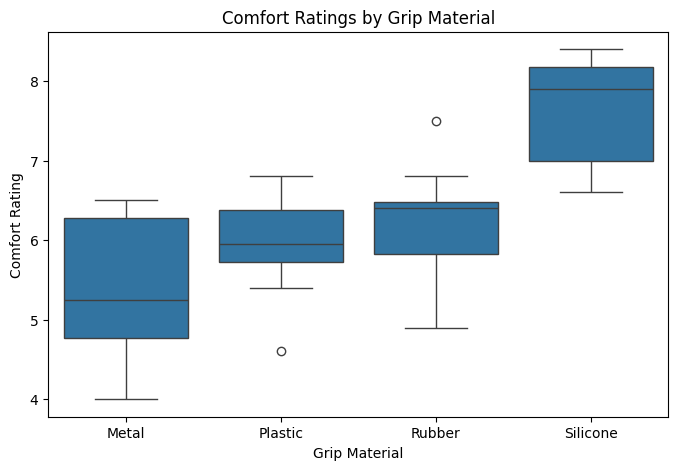

In [7]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Material", y="Comfort")
plt.title("Comfort Ratings by Grip Material")
plt.xlabel("Grip Material")
plt.ylabel("Comfort Rating")
plt.show()

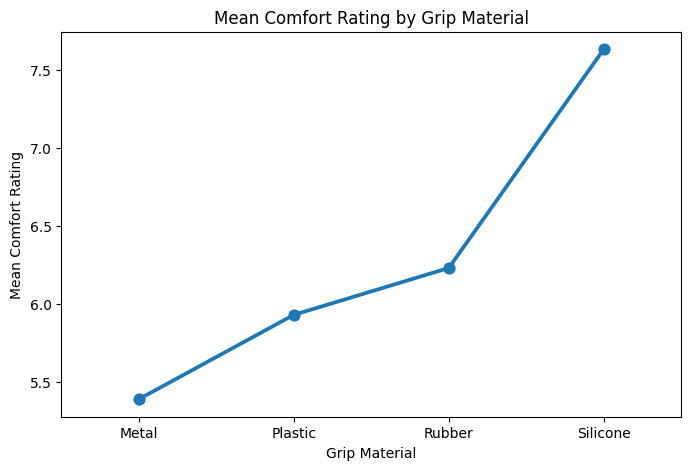


Mean comfort by material:

   Material  Comfort
0     Metal     5.39
1   Plastic     5.93
2    Rubber     6.23
3  Silicone     7.63


In [5]:
# Mean comfort rating by material
mean_stats = df.groupby("Material", observed=False)["Comfort"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.pointplot(data=df, x="Material", y="Comfort", errorbar=None)
plt.title("Mean Comfort Rating by Grip Material")
plt.xlabel("Grip Material")
plt.ylabel("Mean Comfort Rating")
plt.show()

print("\nMean comfort by material:\n")
print(mean_stats.round(2))

*Question 7.* Build a one-way ANOVA model. Test the assumption of normality using *both* a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

A one-way ANOVA model was constructed to evaluate whether the mean comfort ratings differ among the four grip materials (metal, plastic, rubber, and silicone). The model was specified with comfort rating as the response variable and grip material as the categorical explanatory variable.

To assess the normality assumption of the ANOVA model, both a statistical test and a visual method were used. First, the Shapiro–Wilk test was applied to the residuals from the ANOVA model. The Shapiro–Wilk test produced a p-value of 0.387. Since this p-value is greater than 0.05, there is insufficient evidence to reject the null hypothesis of normality. Therefore, the test suggests that the residuals are approximately normally distributed.

In addition to the statistical test, a Q-Q plot of the residuals was examined. The points in the Q-Q plot fall closely along the reference line, with only minor deviations at the tails. This indicates that the residuals follow an approximately normal distribution.

Based on both the Shapiro–Wilk test and the Q-Q plot, the results support the assumption of normality for the ANOVA model.

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit ANOVA model
model = ols('Comfort ~ C(Material)', data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Table:")
print(anova_table)

ANOVA Table:
             sum_sq    df          F        PR(>F)
C(Material)  27.387   3.0  17.070642  4.616153e-07
Residual     19.252  36.0        NaN           NaN


In [15]:
from scipy.stats import shapiro

residuals = model.resid

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk Test Statistic: 0.9710174538151857
p-value: 0.3874084700249114


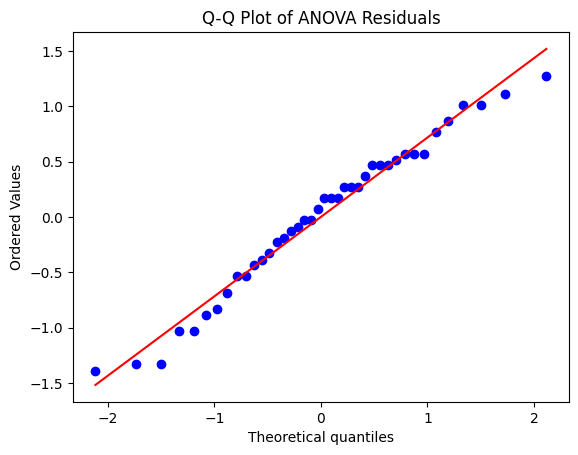

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

*Question 8.* Test the assumption of homogeneity of variance using *both* a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

The assumption of homogeneity of variance was evaluated using both a statistical test and a visual method.

First, Levene’s test was used to statistically assess whether the variances of comfort ratings are equal across the four grip material groups. The Levene test produced a test statistic of 0.578 with a p-value of 0.633. Since the p-value is greater than 0.05, there is insufficient evidence to reject the null hypothesis of equal variances. Therefore, the statistical test suggests that the variances of the groups are not significantly different.

A visual assessment was also conducted using a residuals versus fitted values plot. In this plot, the residuals appear randomly scattered around the horizontal zero line without any clear pattern or funnel-shaped spread. The variability of the residuals appears relatively consistent across the fitted values.

Based on both the Levene test and the residuals versus fitted plot, the assumption of homogeneity of variance appears to be satisfied for the ANOVA model.

In [20]:
from scipy.stats import levene

metal = df[df["Material"]=="Metal"]["Comfort"]
plastic = df[df["Material"]=="Plastic"]["Comfort"]
rubber = df[df["Material"]=="Rubber"]["Comfort"]
silicone = df[df["Material"]=="Silicone"]["Comfort"]

stat, p = levene(metal, plastic, rubber, silicone)

print("Levene Test Statistic:", stat)
print("p-value:", p)

Levene Test Statistic: 0.5784720527215036
p-value: 0.6329252655165909


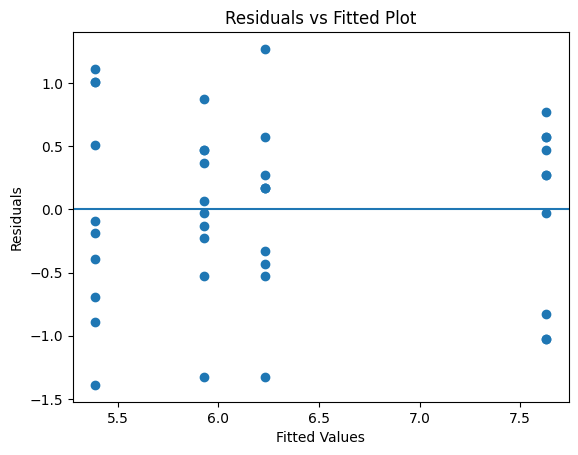

In [21]:
fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Plot")
plt.show()

*Question 9.* Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

The one-way ANOVA test was used to evaluate whether the mean comfort ratings differ among the four grip materials.

From the ANOVA table, the F-statistic for the treatment factor (Material) is 17.07, and the associated p-value is 4.62 × 10⁻⁷.

Since the p-value is far less than the significance level of 0.05, we reject the null hypothesis. This indicates that there is strong statistical evidence that the mean comfort ratings are not equal across all grip materials.

Therefore, the alternative hypothesis is more strongly supported. This suggests that at least one grip material has a significantly different mean comfort rating compared to the others.

*Question 10.* If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Since the ANOVA results supported the alternative hypothesis, Tukey’s Honest Significant Difference (HSD) post-hoc test was conducted to determine which grip material types differ significantly in mean comfort ratings.

The Tukey HSD results show that silicone is significantly different from several other materials. Specifically, silicone has significantly higher mean comfort ratings compared to metal (mean difference = 2.24, p < 0.001), plastic (mean difference = 1.70, p < 0.001), and rubber (mean difference = 1.40, p = 0.0007).

However, the remaining comparisons were not statistically significant at the 0.05 significance level. There was no significant difference between metal and plastic (p = 0.3639), metal and rubber (p = 0.0662), or plastic and rubber (p = 0.7958).

Overall, these results indicate that silicone grips provide significantly higher comfort ratings than the other grip materials, while the differences among metal, plastic, and rubber are not statistically significant.

In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df["Comfort"],
                          groups=df["Material"],
                          alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


*Question 11.* Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

This study was conducted to evaluate whether different controller grip materials influence the perceived comfort level reported by professional gamers. A one-way ANOVA was used to compare the mean comfort ratings among four materials: metal, plastic, rubber, and silicone.

The exploratory analysis suggested noticeable differences in comfort ratings across the materials, with silicone appearing to have the highest average comfort rating and metal the lowest. The one-way ANOVA confirmed that these differences were statistically significant (F = 17.07, p < 0.001), indicating that the mean comfort ratings are not equal across the four grip materials. Because the null hypothesis was rejected, a Tukey HSD post-hoc test was conducted to determine which materials differed from each other.

The Tukey test revealed that silicone grips had significantly higher comfort ratings compared to metal, plastic, and rubber. However, the differences among metal, plastic, and rubber were not statistically significant. These results suggest that silicone grips provide a noticeably higher level of comfort compared to the other materials tested.

Despite these findings, several limitations should be considered. First, the sample size was relatively small, with only ten prototypes tested for each material type. Second, the experiment only involved gamers playing a single game (Apex Legends), which may limit the generalizability of the results to other types of games or gaming styles. Additionally, individual factors such as hand size, grip preference, playing intensity, and sweating could influence comfort ratings but were not controlled in this experiment.

Future studies could address these limitations by increasing the sample size and including a more diverse group of gamers. Researchers could also test the controller grips across different types of games and longer testing periods to better evaluate long-term comfort. In addition, collecting information about user characteristics such as hand size or grip style could help further understand how different materials affect comfort for different types of players.

*PART 2 INSTRUCTIONS:* The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the Nursing VR Study.xlsx file. With these data, your tasks are:

*Question 1.* Briefly define the objective of this experiment

The objective of this experiment is to evaluate whether a virtual reality (VR) teaching session improves undergraduate nursing students’ attitudes toward elderly people compared to a traditional teaching session, while accounting for whether students have prior working experience with elderly patients.

*Question 2.* Specify the outcome variable

The outcome variable is the quiz score measuring attitudes toward elderly people, with scores ranging from 0 to 50, where higher scores indicate more favorable attitudes toward elderly people.

This is a quantitative response variable.

*Question 3.* Specify the independent variable and blocking factor. What are some possible lurking variables?

The independent variable (treatment factor) is:

Teaching Method

VR class session

Traditional class session

The blocking factor is:

Prior working experience with elderly people

Prior experience

No prior experience

Possible lurking variables include:

students’ prior attitudes toward elderly people

level of interest in geriatric care

familiarity with VR technology

engagement during the class session

academic ability

*Question 4.* Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

A randomized block design is appropriate because prior working experience with elderly people may influence students’ attitudes and quiz scores. Students who have already worked with elderly patients may naturally have more favorable attitudes regardless of the teaching method.

By using prior experience as a blocking factor, students are grouped based on whether they have prior experience before comparing the VR and traditional teaching methods. This helps control for the effect of prior experience and allows a more accurate comparison of the two teaching methods.

A completely randomized design would not be appropriate because it would ignore the effect of prior experience. If one teaching method group contained more students with prior elderly-care experience, the results could be biased. In that case, differences in quiz scores might be caused by prior experience rather than the teaching method.

*Question 5.* State the null and alternative hypotheses for this experiment.

Null hypothesis (H₀):

μVR = μTraditional

The mean quiz score is the same for students who used the VR session and those who used the traditional session.

Alternative hypothesis (Hₐ):

μVR ≠ μTraditional

The mean quiz score differs between students who used the VR session and those who used the traditional session.

*Question 6.* Perform appropriate exploratory analysis, including summary statistics *and* data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

Exploratory analysis was conducted using summary statistics and visualizations to examine the quiz scores across the different teaching methods and prior experience groups.

The summary statistics provide an initial comparison of quiz scores for students who participated in the VR session and those who participated in the traditional session. In addition, the results were examined separately for students with and without prior experience working with elderly people. The mean quiz scores appear to differ between the teaching methods and between the experience groups.

The boxplot visualization further illustrates the distribution of quiz scores across the groups. The plot allows comparison of both the central tendency and the spread of scores for students in the VR and traditional teaching sessions while accounting for prior experience. Differences in the centers of the boxes suggest that one teaching method may lead to higher quiz scores than the other.

The mean plot also shows differences in the average quiz scores between the VR and traditional teaching methods within each experience group. These differences suggest that the teaching method may influence students’ attitudes toward elderly people.

Overall, the exploratory analysis suggests that quiz scores may differ between the VR and traditional teaching methods. Therefore, the results of the exploratory analysis appear to support the alternative hypothesis more strongly than the null hypothesis. However, formal statistical testing is required to determine whether these observed differences are statistically significant.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Nursing VR Study.xlsx")

print(df.head())
print(df.shape)
print(df.dtypes)

        Method           Experience  Score
0  Traditional     Prior Experience     26
1  Traditional  No Prior Experience     31
2  Traditional     Prior Experience     35
3  Traditional  No Prior Experience     37
4  Traditional     Prior Experience     30
(40, 3)
Method        object
Experience    object
Score          int64
dtype: object


In [24]:
summary_stats = df.groupby(["Method","Experience"])["Score"].agg(
    n="count",
    mean="mean",
    std="std",
    median="median",
    min="min",
    max="max"
).round(2)

print(summary_stats)

                                  n  mean   std  median  min  max
Method      Experience                                           
Traditional No Prior Experience  10  30.7  4.69    31.0   23   38
            Prior Experience     10  30.9  8.56    29.5   15   45
VR          No Prior Experience  10  37.3  7.92    40.5   26   46
            Prior Experience     10  39.7  6.06    40.0   29   49


In [25]:
df.groupby("Method")["Score"].mean().round(2)

,Score
Method,
Traditional,30.8
VR,38.5


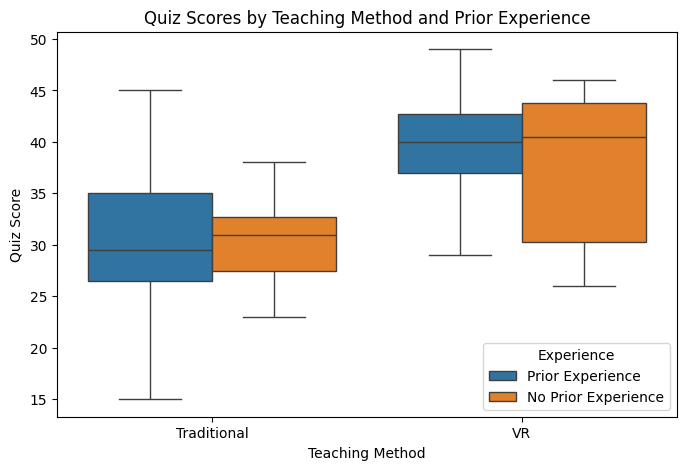

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Method", y="Score", hue="Experience")

plt.title("Quiz Scores by Teaching Method and Prior Experience")
plt.xlabel("Teaching Method")
plt.ylabel("Quiz Score")

plt.show()

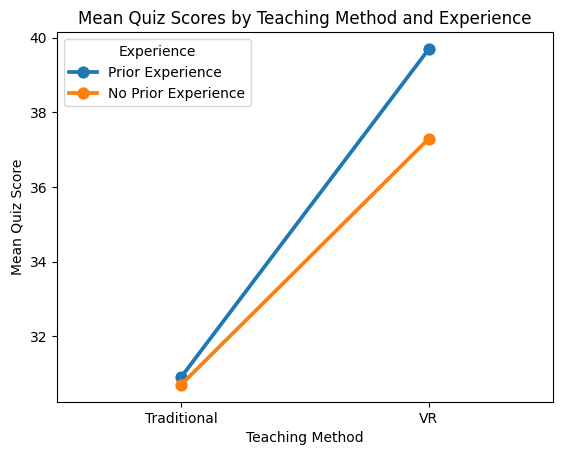

In [27]:
sns.pointplot(data=df, x="Method", y="Score", hue="Experience", errorbar=None)

plt.title("Mean Quiz Scores by Teaching Method and Experience")
plt.xlabel("Teaching Method")
plt.ylabel("Mean Quiz Score")

plt.show()

*Question 7.* Build a two-way ANOVA model. Test the assumption of normality using *both* a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

A two-way ANOVA model was constructed to evaluate whether quiz scores differ between the two teaching methods (VR and Traditional) while accounting for prior working experience with elderly people as a blocking factor. The model included teaching method as the treatment factor and prior experience as the blocking factor.

To assess the normality assumption of the ANOVA model, both a statistical test and a visual method were used. First, the Shapiro–Wilk test was applied to the residuals of the model. The test produced a p-value of 0.917. Since this p-value is greater than 0.05, there is insufficient evidence to reject the null hypothesis of normality. This indicates that the residuals are approximately normally distributed.

In addition, a Q-Q plot of the residuals was examined. The points in the Q-Q plot lie close to the reference line, with only minor deviations at the extremes. This visual pattern suggests that the residuals follow a roughly normal distribution.

Based on both the Shapiro–Wilk test and the Q-Q plot, the results support the assumption of normality for the two-way ANOVA model.

In [28]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Two-way ANOVA model (Treatment + Block)
model = ols('Score ~ C(Method) + C(Experience)', data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

               sum_sq    df          F    PR(>F)
C(Method)       592.9   1.0  12.441048  0.001140
C(Experience)    16.9   1.0   0.354619  0.555135
Residual       1763.3  37.0        NaN       NaN


In [29]:
from scipy.stats import shapiro

residuals = model.resid

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk Test Statistic: 0.9869121871043949
p-value: 0.9172749088112122


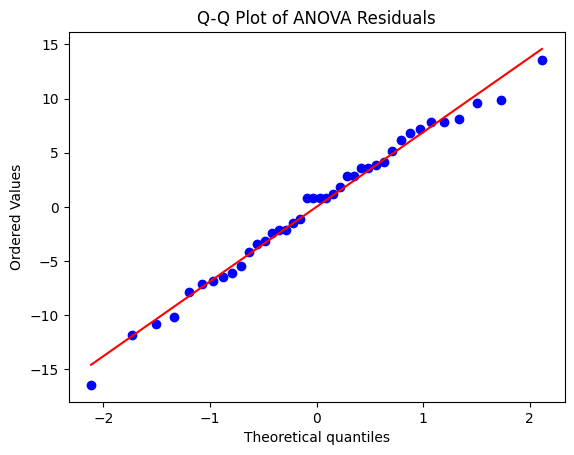

In [30]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

*Question 8.* Test the assumption of homogeneity of variance using *both* a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

The assumption of homogeneity of variance was evaluated using both a statistical test and a visual method.

First, Levene’s test was used to determine whether the variances of quiz scores are equal across the groups defined by teaching method and prior experience. The test produced a test statistic of 1.164 with a p-value of 0.337. Since the p-value is greater than 0.05, there is insufficient evidence to reject the null hypothesis of equal variances. Therefore, the statistical test suggests that the variances across the groups are not significantly different.

A visual assessment was also conducted using a residuals versus fitted values plot. In this plot, the residuals appear randomly scattered around the horizontal zero line without any clear pattern or funnel-shaped spread. The variability of the residuals appears relatively consistent across the fitted values.

Based on both the Levene test and the residuals versus fitted plot, the results support the assumption of homogeneity of variance for the two-way ANOVA model.

In [31]:
from scipy.stats import levene

# create groups based on Method and Experience
groups = [g["Score"].values for _, g in df.groupby(["Method","Experience"])]

stat, p = levene(*groups)

print("Levene Test Statistic:", stat)
print("p-value:", p)

Levene Test Statistic: 1.1638738994603803
p-value: 0.33694602944077134


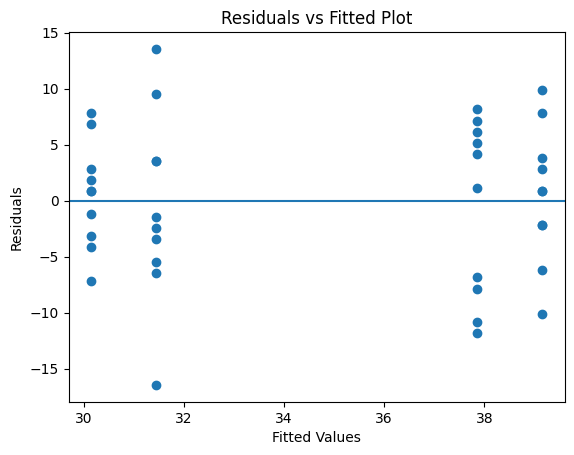

In [32]:
fitted = model.fittedvalues
residuals = model.resid

import matplotlib.pyplot as plt

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Plot")
plt.show()

*Question 9.* Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

For the treatment effect (teaching method), the two-way ANOVA produced an F-statistic of 12.44 with an associated p-value of 0.00114.

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis. Therefore, the alternative hypothesis is more strongly supported.

This means there is strong statistical evidence that the mean quiz score differs between the VR teaching method and the traditional teaching method. The small p-value indicates that the observed difference in mean scores is unlikely to be due to random chance alone.

*Question 10.* If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Since the ANOVA results supported the alternative hypothesis, Tukey’s Honest Significant Difference (HSD) post-hoc test was conducted to determine which levels of the treatment factor differ significantly.

The Tukey HSD test compared the mean quiz scores between the traditional teaching method and the VR teaching method. The results show a mean difference of 7.7 points between the two methods with a p-value of 0.001. Since this p-value is less than 0.05, the difference is statistically significant.

This result indicates that the VR teaching method produces significantly different quiz scores compared to the traditional teaching method. The confidence interval for the mean difference (3.32 to 12.08) does not include zero, which further confirms that the difference between the two teaching methods is statistically significant.

Therefore, the Tukey HSD test supports the conclusion that the teaching method has a significant effect on students’ attitudes toward elderly people.

In [33]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["Score"],
    groups=df["Method"],
    alpha=0.05
)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


*Question 11.* Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

This experiment was conducted to evaluate whether a virtual reality (VR) teaching session is more effective than a traditional teaching method in improving nursing students’ attitudes toward elderly people. A two-way ANOVA was used to compare quiz scores between the two teaching methods while accounting for prior working experience with elderly people as a blocking factor.

The exploratory analysis suggested differences in quiz scores between the VR and traditional teaching groups. The two-way ANOVA results confirmed that the teaching method had a statistically significant effect on quiz scores (F = 12.44, p = 0.00114). This indicates that the mean quiz scores differ between students who participated in the VR session and those who participated in the traditional teaching session. In contrast, the blocking factor of prior working experience with elderly people was not statistically significant (p = 0.555), suggesting that prior experience did not have a strong effect on the quiz scores in this study.

Because the treatment effect was significant, Tukey’s HSD post-hoc test was performed. The results showed that students who participated in the VR teaching session scored significantly higher than those who participated in the traditional teaching session, with a mean difference of 7.7 points. This suggests that the VR teaching method may be more effective in improving students’ attitudes toward elderly people.

Despite these findings, several limitations should be considered. First, the sample size was relatively small, with only 40 students included in the study. Second, the experiment was conducted during a single class session, which may not fully capture long-term learning effects. Additionally, other factors such as students’ prior attitudes toward elderly people, familiarity with VR technology, or engagement during the session may have influenced the results but were not directly controlled in the study.

Future research could expand the study by including a larger and more diverse sample of students and testing the VR program across multiple class sessions or institutions. Researchers could also measure students’ attitudes before and after the intervention to better evaluate changes in attitudes over time. Collecting additional information about students’ backgrounds, technology familiarity, and engagement levels may also help provide a more complete understanding of the effectiveness of VR-based educational tools.

*PART 3 INSTRUCTIONS:* Please briefly respond to the following questions:

*Question 1.* Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

A one-factor completely randomized design (CRD) is often not appropriate for studies involving human participants because people naturally differ in many ways, such as age, experience, background, ability, and personal preferences. These differences can influence the outcome of the study. If these factors are not controlled, they may introduce extra variability and make it difficult to determine whether the observed effects are actually caused by the treatment or by individual differences among participants.

*Question 2.* What is the purpose of post-hoc tests?

The purpose of post-hoc tests is to identify which specific group means are significantly different from each other after an ANOVA test indicates that there is a significant overall difference among groups. While ANOVA tells us that at least one group differs, post-hoc tests such as Tukey’s HSD help determine exactly which groups are different.

*Question 3.* Explain the difference between RBD and LSD.

A Randomized Block Design (RBD) groups experimental units into blocks based on a factor that may influence the response variable. Treatments are then randomly assigned within each block. This design helps reduce variability caused by the blocking factor and allows for a more precise comparison of treatments.

A Latin Square Design (LSD) controls for two blocking factors instead of one. In this design, treatments are arranged in a square grid so that each treatment appears exactly once in each row and each column. This allows researchers to control for two different sources of variability simultaneously.

*Question 4.* Explain why randomization is important in designing experiments.

Randomization is important because it helps prevent bias when assigning treatments to experimental units. By randomly assigning treatments, each unit has an equal chance of receiving any treatment, which helps ensure that other uncontrolled factors are distributed evenly across treatment groups. This improves the validity of the experiment and allows researchers to make more reliable conclusions about treatment effects.

*Question 5.* Explain why replication

Replication involves applying each treatment to multiple experimental units. The purpose of replication is to reduce the effect of random variation and provide a more reliable estimate of treatment effects. Replication also increases the precision of the results and allows researchers to estimate experimental error, which is necessary for conducting statistical tests such as ANOVA.